# Project Exploration

This notebook is her to understand the basic data structures present in the project.
It's more of an exploratory pointer than an actual notebook.

Prerequisites:
- You should have downloaded the twooroom dataset and placed it under <STABLEWM_HOME>/datasets
- You have to run the LeWorldModel training to a point where you have at least one snapshot.
   - Alterntively, you can download a .pt file from huggingface and place it in the <STABLEWM_HOME>/checkpoints directory)

In [1]:
# correct working directory only once 
if not "working_directory_corrected" in vars():
    %cd ..
    working_directory_corrected = True

import os
import stable_worldmodel as swm
import h5py
import matplotlib.pyplot as plt
from einops import rearrange
from torch.utils.data import DataLoader
import torch
import random
import numpy as np

c:\Users\frank\Documents\Teaching\Projects\JEPAHeuristics\JEPAHeuristics


c:\Users\frank\Documents\Teaching\Projects\JEPAHeuristics\JEPAHeuristics\environment\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# Dataset
Here we load the dataset tworoom and obsere it's properties.

The below cell loads the dataset and prints out all properties.

In [2]:
cache_dir = os.environ.get("LOCAL_DATASET_DIR", None)
dataset = swm.data.load_dataset(
    "tworoom.h5", 
    transform=None, 
    cache_dir=cache_dir, 
    format="hdf5"
)

dataset[0].keys()

dict_keys(['action', 'distance_to_target', 'ep_idx', 'id', 'observation', 'pixels', 'pos_agent', 'pos_target', 'proprio', 'render_time', 'reward', 'step_idx', 'terminated', 'truncated'])

In [3]:
print(dataset[0]["action"])
print(dataset[1]["action"])
print(dataset[2]["action"])
print(dataset[3]["action"])
print(dataset[4]["action"])

tensor([[-0.4363, -1.0000]])
tensor([[-1.,  1.]])
tensor([[-0.3437, -0.5173]])
tensor([[-1., -1.]])
tensor([[-0.2429,  1.0000]])


For us, the main properties are the following:
- "pixels": a representation of the image in rgb images with resolution 224 x 224
- "pos_agent": the position of the agent on the image in two-dimensional coordinates between (0,0) and (244,244)
- "action": the action performed at the current point. Seems to a two-dimenional movement vector between (-1,-1) and (1,1)

Let's visualize the image data now (column pixels). Below we'll visualize nine random states from the dataset.

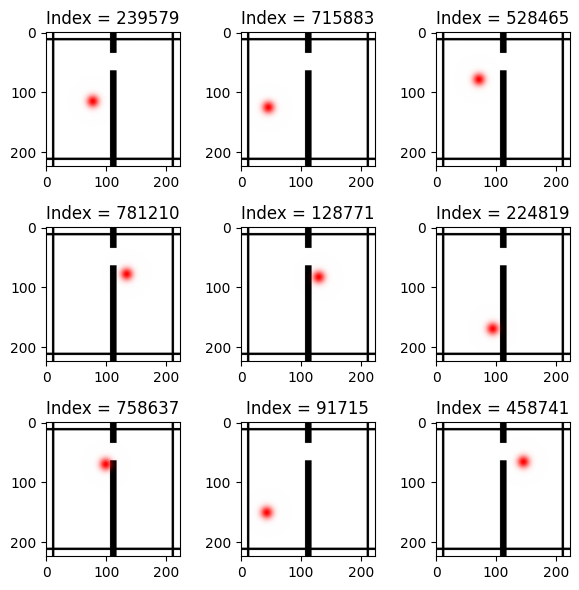

In [4]:

fig, axes = plt.subplots(nrows=3, ncols=3,figsize=(3*2, 3*2))
for index in range(9):
    data_index = random.randint(0,len(dataset))
    axes[index//3][index%3].set_title(label=f"Index = {data_index}")
    # pytorch format is (3,244,244). Need to permute into (244,244,3)
    axes[index//3][index%3].imshow(dataset[data_index]["pixels"][0].permute(1,2,0))

plt.tight_layout()

Next, let us illustrate the meaning of "pos_agent" and "action".
"pos_agent" is the current position of the agent. It should coincide with the center of the red dot showin in the image. 

"action" is the action performed in the current state. It takes effect in the next one. This means an action performed in image 0 will have an effect in image 1 and move the position of the agent. Empirically, it seems that the agent will move 5 times the action vector. This means, we can predict the next position with the following formula:

- $next\_position = current\_position + action*5$

Below we can test this formula. No matter which index within the dataset you choose, the predicted next position should always be the same - or very close to - the actual next position.


In [5]:
index = 0

print("state", dataset[index]["pos_agent"])
print("action", dataset[index]["action"])
print("predicted next state", dataset[index]["pos_agent"] + 5*dataset[index]["action"])
print("next state",dataset[index+1]["pos_agent"])


state tensor([[169.4324,  65.9336]])
action tensor([[-0.4363, -1.0000]])
predicted next state tensor([[167.2509,  60.9336]])
next state tensor([[167.2509,  60.9336]])


# Model Data Preprocessing
For the model, the dataset looks slightly different. The main reason is that the model is configured with the following parameters:
- $frameskip$: 5 (meaning the model predicts five steps into the future at a time)
- $history\_size$: 3 (meaning the model predicts the future based on the preceding three steps)

This has a few consequences:
- The model loads a vector of five actions at once. The action vector becomes 10-dimensional (2 * 5) rather than two-dimensional.
- The model wants three states as input, rather than once. 

Let us now load our data again in the shape it is convenient for the model to consume. We'll call it dataset_for_model so we can distinguish our two datasets and compare them to see what's going on.
First off, let's load our dataset.

In [ ]:
cache_dir = os.environ.get("LOCAL_DATASET_DIR", None)
dataset_for_model = swm.data.load_dataset(
    "tworoom.h5", 
    transform=None, 
    cache_dir=cache_dir, 
    format="hdf5", 
    frameskip = 5, # make predictions of five actions at once.
    num_steps = 3, # make predictions for three consecutive steps.
    keys_to_load = ["pixels", "action", "proprio"], # restrict to keys we actually need.
    keys_to_cache= ["action", "proprio"]
)


10:53:35 | INFO  | __init__.py | Cached 'action' from 'C:\Users\frank\.stable_worldmodel\datasets\tworoom.h5'


10:53:35 | INFO  | __init__.py | Cached 'proprio' from 'C:\Users\frank\.stable_worldmodel\datasets\tworoom.h5'


Let's look at the states in the original and the new dataset. We will use "proprio" here as it's easier to see the state in it's numeric property. We will assume that the pixel representation correctly represents the coordinates in this property. 

In [33]:
i = 0
print(f"original state {i}:", dataset[i]["proprio"])
print(f"original state {i+5}:", dataset[i+5]["proprio"])
print(f"original state {i+10}:", dataset[i+10]["proprio"])
print(f"combined state {i}", dataset_for_model[i]["proprio"])

original state 0: tensor([[169.4324,  65.9336]])
original state 5: tensor([[154.3182,  63.3471]])
original state 10: tensor([[133.3991,  57.7123]])
combined state 0 tensor([[169.4324,  65.9336],
        [154.3182,  63.3471],
        [133.3991,  57.7123]])


As we can see the combined state for the model dataset consists of states 0, 5 and 10 of the original dataset.
You can set the variable i to different values in the above cell to convince yourself that this is always the case. For a given index, the model dataset at position i always consists if i, i+5 and i+10.
It's three consecutive states, each five steps into the future. 



Looking at the actions, we can see something similar.
Let's visualize the first 15 actions in the original dataset and the combined action vector for the combined dataset

In [34]:
for i in range(15):
    print(f"original action {i}", dataset[i]["action"])
print("actions for model", dataset_for_model[0]["action"])



original action 0 tensor([[-0.4363, -1.0000]])
original action 1 tensor([[-1.,  1.]])
original action 2 tensor([[-0.3437, -0.5173]])
original action 3 tensor([[-1., -1.]])
original action 4 tensor([[-0.2429,  1.0000]])
original action 5 tensor([[-0.6653, -0.3743]])
original action 6 tensor([[-1.0000,  0.1905]])
original action 7 tensor([[-0.8120,  1.0000]])
original action 8 tensor([[-1., -1.]])
original action 9 tensor([[-0.7065, -0.9432]])
original action 10 tensor([[0.7782, 0.0447]])
original action 11 tensor([[-1.0000,  0.6388]])
original action 12 tensor([[-0.4826, -1.0000]])
original action 13 tensor([[-1.0000,  0.0951]])
original action 14 tensor([[-1.0000,  0.0775]])
actions for model tensor([[-0.4363, -1.0000, -1.0000,  1.0000, -0.3437, -0.5173, -1.0000, -1.0000,
         -0.2429,  1.0000],
        [-0.6653, -0.3743, -1.0000,  0.1905, -0.8120,  1.0000, -1.0000, -1.0000,
         -0.7065, -0.9432],
        [ 0.7782,  0.0447, -1.0000,  0.6388, -0.4826, -1.0000, -1.0000,  0.0951,

Above we can see that the model dataset consists of three action vectors (one for the three predictions) and each of these vectors consist of 5 actions. They correspond to each other exactly. The first model vector encompasses the first five actions for the original dataset.


# Encoding

Now let's get the model into play and use it to encode states and actions in the embedded space.

The cell below loads the model. It assumes you have a snapshot located at <STABLEWM_HOME>/checkpoints/lewm/weights_epoch_100.pt. If your checkpoint is somewhere else (e.g., because you have downloaded form huggingface) you will need to adjust the location in the cell below.

In [164]:

model = swm.wm.utils.load_pretrained("lewm/weights_epoch_100.pt")

13:44:46 | INFO  | utils.py    | Created ViT-tiny from scratch with config: {'hidden_size': 192, 'num_hidden_layers': 12, 'num_attention_heads': 3, 'intermediate_size': 768, 'image_size': 224, 'patch_size': 14}


Next we'll create encodings for all of our data. For this we create a data_loader (as it does some conversion and formatting that is expected by the model) and then call model.encode to encode both the states and actions. 
We'll work with a batch size of only 10 to showcase the batch size. We don't use the batch size here.

In [165]:
data_loader = DataLoader(dataset_for_model, batch_size=10)
batch = next(iter(data_loader))
batch["action"] = torch.nan_to_num(batch["action"], 0.0)
batch = model.encode(batch)
print("state encoding:", batch["emb"].shape)
print("action encoding:", batch["act_emb"].shape)

state encoding: torch.Size([10, 3, 192])
action encoding: torch.Size([10, 3, 192])


The encoder has added two columns to our dataset: 
- $emb$ is the embedding of the state. Each of the three states is encoded as a 192-sized vector.
- $act\_emb$ the embedding of actions. Each of the five-action vectors is encodes as a 192-sized vector.

Embeddings of states and actions all have 192 dimensions.

# predicting action sequences
Next let's see how we can use the model to predict action sequences.
For this we will use the function "rollout" provided by the model. This function takes as input:
- The initial history, a tensor of shape (batch_size, number_samples, history_size, image_dimensions)
- actions: a tesnor of shape (batch_size, number_samples, number_actions, action_dimensions)

Note that this function works in the original and not the embedded space. The image_dimensions are those of the original images (3,244,244) and the action_dimension is 10 (frameskip 5 still applies). We will use a history_size of 3.

The number of actions should always be at least history_size -1 (because those are the actions leading from one history state to the next.) Anything beyond this will be predictions for the future. For example, if we supply 5 actions, the first two of them would be interpreted as transition between the three history states and the last three of them would create new states. 

Batch_size and number_samples can be used to do multiple calculations in parallel. For our purposes here, we can ignore them and set them to 1. 

Accordingly, the input we need to create is:
- initial history of shape (1,1,3,3,244,244)
- actions of shape (1,1,2+X,10)

where X is the number of states we want to predict with these actions.

Let's set this up and run the prediction below:



In [178]:

# create info object with pixels of shape (1,1,3,3,244,244)
info = {
    "pixels":dataset_for_model[0]["pixels"].clone().unsqueeze(0).unsqueeze(0)
}

# create base actions (shape (2,10))
base_action_sequence = dataset_for_model[0]["action"][0:2]

# create 3 additional actions (shape (3,10))
additional_actions = torch.tensor([[0,0,0,0,0,0,0,0,0,0],
                                   [1,1,1,1,1,1,1,1,1,1],
                                   [-1,-1,-1,-1,-1,-1,-1,-1,-1,-1]])

# add base and additional actions (shape (5,10)) and unsqueeze them to shape (1,1,5,10)
complete_action_sequence = torch.cat([base_action_sequence,additional_actions], dim = 0)
complete_action_sequence = complete_action_sequence.unsqueeze(0).unsqueeze(0)

# run model.
with torch.no_grad():
    rollout_output = model.rollout(
        info=info, 
        action_sequence=complete_action_sequence, 
        history_size=3
    )


calling predict
calling forward with torch.Size([1, 3, 192]) torch.Size([1, 3, 192])
step1:  torch.Size([1, 3, 192])
step2:  torch.Size([3, 192])
step2:  torch.Size([1, 3, 192])
calling predict
calling forward with torch.Size([1, 3, 192]) torch.Size([1, 3, 192])
step1:  torch.Size([1, 3, 192])
step2:  torch.Size([3, 192])
step2:  torch.Size([1, 3, 192])
calling predict
calling forward with torch.Size([1, 3, 192]) torch.Size([1, 3, 192])
step1:  torch.Size([1, 3, 192])
step2:  torch.Size([3, 192])
step2:  torch.Size([1, 3, 192])


The rollout function adds the following additional data to our dictionary $info":
- $emb$: the embedding of the original states (shape (1,1,3,192))
- $predicted\_emb$: the embeddings of the predictions (shape (1,1,3+X,192))
with X the number of additional actions applied

The first three states in $emb$ and $predicted\_emb$ shoud be the same. We can convince ourselves of this in the following cell.

In [179]:
print("distance first element", torch.linalg.norm(rollout_output["emb"][0][0][0] - rollout_output["predicted_emb"][0][0][0]))
print("distance second element", torch.linalg.norm(rollout_output["emb"][0][0][1] - rollout_output["predicted_emb"][0][0][1]))
print("distance third element", torch.linalg.norm(rollout_output["emb"][0][0][2] - rollout_output["predicted_emb"][0][0][2]))


distance first element tensor(0.)
distance second element tensor(0.)
distance third element tensor(0.)


The additional elements in $predicted\_emb$ are new states that resulted from applying the actions auto-regressively.
We can also measure how much each action changed the state in the following cell.

In [180]:
print("distance state 2->3", torch.linalg.norm(rollout_output["predicted_emb"][0][0][2] - rollout_output["predicted_emb"][0][0][3]))
print("distance state 3->4", torch.linalg.norm(rollout_output["predicted_emb"][0][0][3] - rollout_output["predicted_emb"][0][0][4]))
print("distance state 4->5", torch.linalg.norm(rollout_output["predicted_emb"][0][0][4] - rollout_output["predicted_emb"][0][0][5]))
print("distance state 3->5", torch.linalg.norm(rollout_output["predicted_emb"][0][0][3] - rollout_output["predicted_emb"][0][0][5]))

distance state 2->3 tensor(8.2992)
distance state 3->4 tensor(10.5547)
distance state 4->5 tensor(10.9723)
distance state 3->5 tensor(10.1475)


*NOTE Frank* I noted that the distances above do not fit well to the actual actions we perform (action 0,0,0,0,0,0,0,0,0,0) should not change much while actions (1,1,1,1,1,1,1,1,1,1) and (-1,-1,-1,-1,-1,-1,-1,-1,-1,-1) should reverse each other. I can't explain this right now. Might be a bug in the implementation or that the model I'm using is just not well trained. Please use this with caution.

# Simulation Enviroment
Here should be a showcase of the two rooms simulation environment. We will need this to create custom datasets.

The environment can be found within the stable_worldmodel repository. Below is some simple code that creates a new environment , sets the agent state to 50,150 and renders the image.

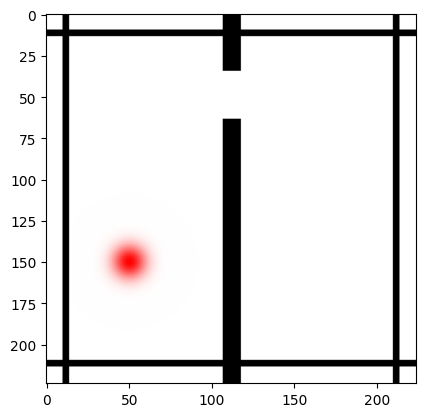

In [197]:
from stable_worldmodel.envs.two_room import TwoRoomEnv

tworooms = TwoRoomEnv()
tworooms.reset(options = {"state":[50,150]})


fig, ax = plt.subplots()
ax.imshow(tworooms.render())
